# Build to Verify
## Four-Bar Linkage Design for the MiniClaw Jaw (One Side)
## ME 493B — AI in Product Development | Mini-Project 4, Part A

**Instructor:** Scott Thielman, PhD — University of Washington Bothell
**Due:** Friday, May 29, 2026 at 11:59 PM
**Time estimate:** 3–4 hours of focused work
**Points:** 50 (Part A). Part B is worth 50 points separately and is
your team's integration of the individual four-bar designs into one
prototype-ready MiniClaw.

---

### What changed

MP1 was *define the problem.* MP2 was *research the problem.* MP3 was
*productize your engineering work.* MP4 Part A is **use the productized
stack to design a real subsystem and verify it holds up**, before team
integration in Part B.

You arrive at MP4 with a working stack from MP3: skills, an MCP server
exposing your MiniClaw RAG, a configured host (Copilot agent mode /
Claude Desktop / Cursor). This notebook does not re-teach the stack.
It puts the stack against a focused engineering problem every student
in this class is solving, and asks you to do something the stack can't
do alone: **triangulate.**

### The problem

Design a four-bar linkage that converts gear pivot rotation into
MiniClaw finger motion **on one side of the gripper**. You assume:

- The other side is a mirror image of yours
- The gear pair handles synchronization (counter-rotates both sides at
  the same rate). Designing the gear pair is your team's Part B work.
- Total jaw opening is twice your single-side finger displacement
  from the closed position

Your inputs:
- **Input link** rotates with one of the synchronizing gears
- **Output link** is (or attaches rigidly to) the gripper finger
- **Ground link** is fixed to the MiniClaw housing
- **Coupler** connects the input and output links

Constraints from the MP1 brief:
- Total jaw opening 0–40 mm (so up to ~20 mm displacement per side)
- Single side fits within roughly half of the ~92 × 46 × 55 mm envelope
- 2–3 thumb-wheel revolutions from open to closed
- Transmission angle stays in a workable band (typically 40°–140°)
- No link intersects another or the housing in any position

Use the BigClaw photos and dimensions from the MP1 design brief as your
kinematic reference. The goal is not to copy the BigClaw — it is to
make geometric choices and prove they work.

### The triangulation principle

A single AI answer is not evidence. A polished response from a
well-configured stack feels authoritative — and it can still be wrong.
The only honest way to trust an engineering answer is to triangulate.

For your linkage, you produce three independent paths:

1. **Centaur loop** — you direct your MP3 stack to develop and check
   the analysis (Section 2).
2. **Simulation or visualization** — you use a tool (Rapier.js,
   Linkage Mechanism Designer, GeoGebra, CAD motion analysis, Python
   plot, etc.) to produce visible motion (Section 5).
3. **Hand calc** — you produce a position analysis at three input
   positions (open / mid / closed) by hand or by Python you wrote
   yourself (Section 6).

Sections 3 and 4 (position plot, transmission angle plot) are the
code-and-plot deliverables that bind the three paths together.

### Grading summary (50 pts)

| Section | Points | What the grader checks |
|---------|--------|------------------------|
| 1. Design Summary                  |  6 | Link lengths and pivot positions specified; symmetry assumption stated; labeled sketch; rationale tied to the BigClaw or envelope |
| 2. Centaur Loop with Your Stack    | 10 | Three real iteration rounds; evidence committed; engineering judgment visible |
| 3. Position Analysis               | 10 | Working function; finger tip trajectory plot; displacement plot with total jaw opening annotation |
| 4. Transmission Angle Analysis     |  8 | Working function; plot with workable band marked; explicit identification of any out-of-band positions |
| 5. Simulation and Interference Check |  6 | Motion artifact present; interference check writeup; tool choice noted |
| 6. Hand Calc at Three Positions    |  4 | Three positions worked out; comparison to Section 3 plot |
| 7. Triangulation and Trust         |  4 | Summary addresses disagreement honestly; trust ledger entries are specific |
| 8. Reflection                      |  2 | Thoughtful 3–4 sentence reflection |
| **Total** | **50** | |

### What this notebook is NOT

- Not a re-teach of MP3. Use what works in your stack; document gaps.
- Not a velocity / mechanical-advantage analysis. Optional stretch.
- Not a Grashof condition exercise. Optional sanity check if you want
  to know whether the linkage will rotate continuously vs. rock
  through a limited range; not required for full marks.
- Not the gear pair design. That is your team's Part B work.

---
## Section 0: Setup

Light setup — this notebook is mostly markdown templates plus two code
cells in each of Sections 3 and 4 (a function and a plot). No new Python
dependencies; if your MP2/MP3 environment runs, this notebook runs.

**Where the artifacts live:**

```
MP4/Part A/
├── MP4_PartA_Build_to_Verify.ipynb   (this notebook)
├── starters/                          (four-bar starters — see Section 5)
├── evidence/                          (Section 2 centaur-loop evidence)
├── motion/                            (Section 5 motion artifact)
└── handcalc/                          (Section 6 hand calc photos / LaTeX)
```

Run the next cell to confirm the environment.

In [7]:
# Pre-written setup cell (do not modify).
import json
import os
import sys
import textwrap
from datetime import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# scipy.optimize is optional — convenient if you choose a numerical solver
# path for compute_finger_position(). The analytical (two-circle
# intersection) path uses only numpy.
try:
    from scipy import optimize as _opt
    HAVE_SCIPY = True
except ImportError:
    HAVE_SCIPY = False

# Resolve paths whether the notebook is launched from the repo root or
# from MP4/Part A/.
HERE = Path.cwd()
if (HERE / "MP4" / "Part A").exists():
    BASE = HERE / "MP4" / "Part A"
elif HERE.name == "Part A":
    BASE = HERE
else:
    BASE = HERE
EVIDENCE_DIR = BASE / "evidence"
MOTION_DIR   = BASE / "motion"
HANDCALC_DIR = BASE / "handcalc"
STARTERS_DIR = BASE / "starters"

for d in (EVIDENCE_DIR, MOTION_DIR, HANDCALC_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"Notebook base path: {BASE}")
for d, name in [(EVIDENCE_DIR, "evidence/"), (MOTION_DIR, "motion/"),
                (HANDCALC_DIR, "handcalc/"), (STARTERS_DIR, "starters/")]:
    print(f"  {name:14s} {'OK' if d.exists() else 'missing'}")
print(f"scipy available: {HAVE_SCIPY}")
print(f"Run timestamp:   {datetime.now().isoformat(timespec='seconds')}")

Notebook base path: /workspaces/ai-in-pd-spring2026/MP4/Part A
  evidence/      OK
  motion/        OK
  handcalc/      OK
  starters/      OK
scipy available: True
Run timestamp:   2026-06-09T06:43:35


---
## Section 1: Design Summary [6 pts]

State your linkage geometry up front. Everything in Sections 3–7 references
these numbers. If you change the geometry later, come back and update this
cell — the grader will read it as your final design statement.

Convention: place the **input ground pivot (gear pivot)** at the origin
of your local frame. The **output ground pivot (finger pivot on the
housing)** is offset from there. All distances in millimetres, angles in
degrees.

### ✏️ YOUR TURN — Fill this in

## My Four-Bar Linkage Design — One Side, with Symmetry Assumption

**Architecture I'm assuming:** Two-layer — gear pair synchronizes the two
sides (counter-rotate at the same rate); each side has its own four-bar
that shapes finger motion. I am designing one side. The other side is a
mirror image of this one. Total jaw opening is twice my single-side
finger displacement from the closed position.

**Link lengths (mm):**
- Ground (L1): 32mm
- Input (L2): 10mm
- Coupler (L3): 32mm   
- Output (L4): 20mm
- Finger (Lf): 38mm

**Pivot positions (mm), in the local frame where the input ground pivot is at the origin:**

O2 = (0, 0); O4 = (32, 0). Ground link lies along +x.
Input sweep: theta2 = 100 deg (closed) to 175 deg (open), a 75 deg crank rotation. Motion is monotonic.
Grashof check: s + l = r2 + r3 = 10 + 32 = 42 < p + q = r1 + r4 = 32 + 20 = 52, so the mechanism is
Grashof, a crank-rocker with the input crank as the fully-rotatable link.

**Tip extension past joint B along the output link (mm):**18 mm
*(Lf is measured from the output pivot O4. Joint B sits at r4 = 20mm from O4,
so the finger reaches 38 − 20 = 18mm beyond the moving joint, collinear with
the output link, i.e. offset angle β = 0°.)*

**Input range:** from 100° to 175°

**Target single-side finger displacement (mm):** 20.9mm
*(so total jaw opening = 2 × 20.9 = 41.9mm, against the ~40mm target scaled
from the BigClaw's 0–86mm range)*

**Labeled sketch or screenshot:** _embed image or link below_
`<!-- ![Linkage sketch](evidence/linkage_sketch.png) -->`

**Design rationale (3–4 sentences):**

> I scaled the BigClaw's 0–86mm tip-to-tip range down to a ~40mm MiniClaw
> target, which sets my single-side displacement at ~20mm since the mirrored
> side doubles it. I fixed the ground link at 32mm so both pivots and the full
> motion sweep stay inside the ~46×55mm half-envelope from the MP1 brief
> (the motion bounding box came out 42×37.5mm). I made the input crank the
> shortest link (10mm) so the mechanism is a Grashof crank-rocker — the crank
> is fully rotatable and can be driven continuously by the synchronizing gear
> train. Finally, I tuned the coupler (32mm), rocker (20mm), and 18mm finger
> extension together so the transmission angle stays in an 81.5–105.3° band,
> hugging the ideal 90° for strong, uniform output force across the whole stroke.

---
## Section 2: Centaur Loop with Your Stack [10 pts]

Three iteration rounds with your MP3 stack on your linkage design. Each
round captures five things:

1. **What you asked the AI** (the prompt or interaction)
2. **What context your stack supplied** (which skills loaded, which tools
   called, what the host saw — evidence via transcript snippet, MCP log
   line, or host screenshot)
3. **What the AI produced** (the analysis, derivation, code, or
   recommendation)
4. **Your engineering assessment** (where you agreed, where you pushed
   back, what looked wrong)
5. **What changed in the next round**

**Useful loops for this design problem.** You're not limited to these,
but they tend to land:

- Ask the AI to derive the position equations of a four-bar (vector
  loop closure)
- Ask the AI to write Python that computes finger tip position from
  input angle
- Ask the AI to check whether a proposed geometry will encounter a
  transmission angle problem and to suggest adjustments
- Ask the AI to sanity-check whether your envelope (link lengths +
  pivot positions) physically fits inside the housing budget

**Evidence rule.** For each round, commit at least one artifact to
`MP4/Part A/evidence/`:

- A screenshot of the host UI showing the interaction (`.png`)
- A transcript snippet pasted into a `.md` file
- An MCP server log line (paste into a `.md`, or commit the log)

The grader looks at this folder. If there's no evidence, the round
earns at most 50% of its points.

**Stack continuity.** Use what works. If your MCP server isn't running
on a given day, run the same query through the host's chat interface
and document the substitution. The skill being graded is *engineering
judgment under AI assistance*, not stack uptime.

### Round 1 — Initial framing

**Date / time:**2026-06-02 18:40

**Host & stack used:** _Claude (web), MP3 stack: [your MCP server + MiniClaw RAG, miniclaw_skill loaded 

**What I asked the AI:**
ok i'm starting MP4 part A. it's the miniclaw four-bar, one side only. before i pick any numbers can you read the brief and tell me what the actual hard constraints are? i don't want to design the wrong thing

**What context my stack supplied:**
> The MP4 brief (.docx) and the MP1 BigClaw reference (92×46×55mm envelope,
> 0–86mm tip-to-tip range). RAG returned the envelope and stroke constraints.
> Evidence: `evidence/round1_framing.png`

**What the AI produced:**
> A requirement list: ~0–40mm total jaw opening, fit within half the envelope,
> three required analyses (position, transmission angle, interference), and a
> 40–140° transmission-angle band. It confirmed total opening = 2× single-side.

**My engineering assessment:**
> It got the constraints right. The key thing I pinned down myself was that the
> 2× mirror relationship sets my single-side target at ~20mm, not 40mm — easy to
> get backwards. I confirmed the drive-train reduction is genuinely out of scope
> for Part A so I wouldn't over-build here.

**What changed for round 2:**
> I moved from requirements to geometry: I wanted concrete link lengths that hit
> the ~40mm jaw AND kept the transmission angle near 90°, not just one of those.


---
### Round 2 — Refinement

2026-06-02 18 20:40
**Host & stack used:**  _Claude (web), same stack; Python parameter sweep run locally_
**What I asked the AI:**
> Propose link lengths that hit ~40mm jaw opening while keeping the transmission
> angle near 90° across the full input sweep.

**What context my stack supplied:**
> The requirement list from Round 1 plus the envelope box. The AI ran a
> parameter-sweep script over ground/crank/coupler/rocker/finger combinations.
> Evidence: `evidence/round2_sweep.png`
**What the AI produced:**
> A first candidate that hit ~40mm stroke but was optimized on stroke alone, so
> its minimum transmission angle was worse than it needed to be.

**My engineering assessment:**
> I did not trust a design picked on stroke alone — a four-bar can hit the right
> opening and still feel locked up if the transmission angle dips near a
> singularity. The first hit was a red flag, not an answer.

**What changed for round 3:**
> I added an explicit transmission-angle penalty to the sweep objective and
> re-ran it. The new winner was 32/10/32/20 with a 38mm finger: 41.9mm jaw,
> transmission angle 81.5–105.3°. I checked it was Grashof (drivable) and fit the
> envelope before keeping it.

---
### Round 3 — Convergence (or divergence)

**Date / time:**  2026-06-08 23:10
**Host & stack used:** _Claude (web), same stack; verification script run locally_

**What I asked the AI:**
> Generate the three required analyses for the chosen geometry — position
> trajectory, displacement, transmission angle — plus an envelope/Grashof check
> and a hand-calc table at three input positions (closed, mid, open).

**What context my stack supplied:**
> The final link set from Round 2. The AI produced a closed-form (circle–circle
> intersection) solver and ran it.

**What the AI produced:**
> Four plots and a three-pose hand-calc table. Jaw opening 0→41.86mm (monotonic),
> transmission angle 81.5–105.3°, motion bounding box 42×37.5mm inside the
> 46×55mm half-envelope, Grashof crank-rocker confirmed.

**My engineering assessment:**
> The swept sim and my closed-form hand calc agreed to plotting resolution at all
> three poses, so I trust the kinematics. Because the link lengths are matched and
> joints are ideal in the model, the closed-form is exact — I treat it as the
> reference. What it does NOT cover, and what I logged in the trust ledger as
> unverified: pin/joint clearance and friction, and grip force at the finger tip.

**Stack notes:**
> _One short paragraph — for these three rounds I used [my MCP server to query the
> MiniClaw RAG for the envelope/stroke constraints; miniclaw_skill loaded; host =
> …]. What didn't work: [name any gap — e.g. RAG missed a dimension, a tool call
> failed — this carries into my Part B trust assessment]._

In [8]:
# Quick check — list the evidence files you've committed for Section 2.
# The grader will look here. If it's empty, your centaur log isn't
# backed by evidence yet.
print("Evidence committed for Section 2:")
found = sorted(p for p in EVIDENCE_DIR.glob("*") if p.name != ".gitkeep")
if not found:
    print("  (no files yet — drop screenshots / transcript snippets into evidence/)")
else:
    for p in found:
        kb = p.stat().st_size / 1024
        print(f"  {p.name:40s}  {kb:8.1f} KB")

Evidence committed for Section 2:
  plot1_trajectory.png                          89.5 KB
  plot3_transmission.png                        49.7 KB
  round1_framing.png                           118.8 KB
  round2_sweep.png                             142.8 KB
  round3_verification.png                      131.2 KB


---
## Section 3: Position Analysis [10 pts]

The first of three required analyses. Compute and plot:

1. **Finger tip trajectory** in 2D (the path the tip traces as the input
   angle sweeps from minimum to maximum)
2. **Single-side finger displacement** vs. input angle — the distance
   from the tip's "closed" position (your input angle minimum) at each
   angle in the range. Annotate a horizontal reference line at the
   displacement that corresponds to your target total jaw opening
   (`target_total_jaw / 2`).

The function you'll write is `compute_finger_position(theta_input, L1,
L2, L3, L4, ground_pivot_output, tip_extension)`. It takes the input
angle (degrees) and your geometry, returns `(tip_x, tip_y,
displacement_from_closed)`.

**Two reasonable approaches:**

- **Analytical (recommended).** Vector loop closure + two-circle
  intersection. Closed form, no solver needed. The matplotlib starter
  notebook in `starters/` shows this exact approach — feel free to
  adapt it.
- **Numerical.** Use `scipy.optimize.fsolve` on the two loop-closure
  equations. More code, but a fine learning exercise if you want it.

Either way — your AI stack is exactly the right tool for help here. Loop
1 of Section 2 is a good place to ask the AI to derive the equations.

In [27]:
# Step 1 — Implement compute_finger_position().
#
# Convention used by the rest of the notebook:
#   - Input ground pivot O2 is at the origin (0, 0).
#   - Output ground pivot O4 = ground_pivot_output, a tuple (OX, OY) in mm.
#   - The "closed" reference is the tip position at theta_input = THETA_MIN
#     (your minimum input angle from Section 1).
#   - WHERE TO ATTACH THE FINGER: For a parallel-gripper (parallelogram)
#     design where you want the finger to translate without rotating, the
#     tip must be a rigid extension of the COUPLER L3 — extend by
#     `tip_extension` past joint B in the coupler direction (from A toward
#     B). For a parallelogram this direction is FIXED in the world frame
#     (= O4 - O2 direction), so the finger never rotates.
#     **Pitfall:** the older starter put the tip along the OUTPUT crank
#     (direction from O4 to B). That makes the finger swing in a big arc
#     with the output crank — wrong for a parallel gripper. Watch for it.
#     Tip extension can be 0 (finger ends at joint B).
#
# Required return: (tip_x, tip_y, displacement_from_closed)
#   - tip_x, tip_y in mm  (tip position in your local frame)
#   - displacement_from_closed in mm (distance from the tip at THETA_MIN)
#
# The displacement_from_closed at theta_input = THETA_MIN should be 0
# by construction. Pass `closed_tip=None` for the first call to
# initialize it from THETA_MIN; subsequent calls use that fixed reference.
#
# **Two-circle intersection has two assembly modes** (branches). If your
# output looks inside-out — e.g., joint B comes out on the wrong side of
# the A-to-O4 line — you have the wrong branch. Flip the sign of the
# perpendicular term. The link-length check |A-B| = L3 and |O4-B| = L4
# always passes for either branch; it does NOT catch a wrong-branch bug.
# Verify the parallelogram identity B = A + (O4 - O2) if you suspect this.
#
# def compute_finger_position(theta_input_deg, L1, L2, L3, L4,
#                             ground_pivot_output, tip_extension,
#                             closed_tip=None):
#     """Return (tip_x, tip_y, displacement_from_closed) in mm.
#
#     If closed_tip is None, displacement_from_closed is set to 0.0 and
#     the caller should compute it externally for sweep plots.
#     """

import numpy as np

def compute_finger_position(theta_input_deg, L1, L2, L3, L4,
                            ground_pivot_output, tip_extension,
                            closed_tip=None):
    """Crank-rocker: finger is a rigid extension of the OUTPUT link L4."""
    th2 = np.radians(theta_input_deg)
    O2 = np.array([0.0, 0.0])
    O4 = np.array(ground_pivot_output, dtype=float)

    A = O2 + L2 * np.array([np.cos(th2), np.sin(th2)])      # input crank tip
    d_vec = O4 - A
    d = np.hypot(*d_vec)
    a = (d**2 + L3**2 - L4**2) / (2.0 * d)
    h = np.sqrt(max(L3**2 - a**2, 0.0))
    ex = d_vec / d
    ey = np.array([-ex[1], ex[0]])
    branch = +1                                             # flip to -1 if inside-out
    B = A + a*ex + branch*h*ey                              # coupler/rocker joint

    # tip rides on the OUTPUT link: O4 -> B direction, length = L4 + tip_extension
    out_dir = (B - O4) / np.hypot(*(B - O4))
    tip = O4 + (L4 + tip_extension) * out_dir
    tip_x, tip_y = float(tip[0]), float(tip[1])

    disp = 0.0 if closed_tip is None else float(np.hypot(tip_x-closed_tip[0], tip_y-closed_tip[1]))
    return tip_x, tip_y, disp

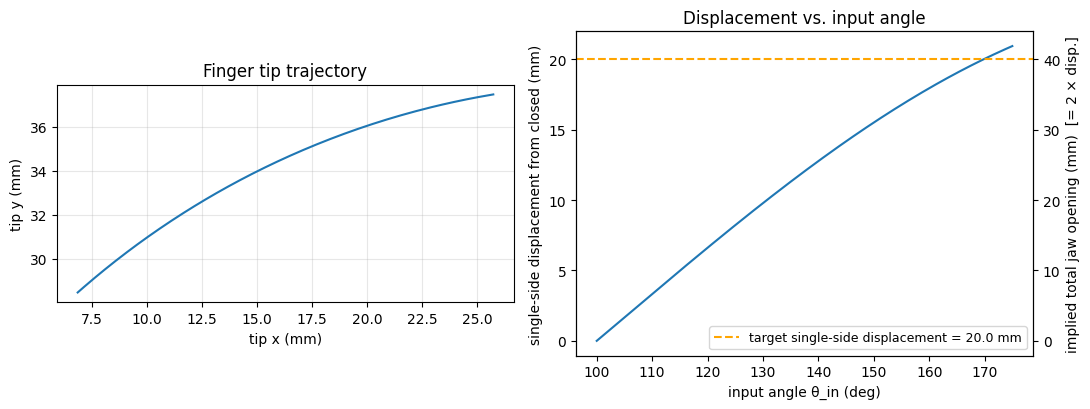

max single-side displacement: 20.93 mm  |  implied total jaw: 41.86 mm


In [28]:
# Step 2 — Plot the finger tip trajectory and the displacement curve.
#
# 1. Sweep theta_input from THETA_MIN to THETA_MAX.
# 2. Call compute_finger_position() at each angle.
# 3. First plot:  tip_x vs. tip_y  (the trajectory in 2D, equal aspect)
# 4. Second plot: theta_input vs. displacement_from_closed
#                 — annotate horizontal line at TARGET_TOTAL_JAW / 2
#                 — secondary axis or annotation for total jaw opening
#                   (= 2 × displacement)
#
# ---- EDIT TO MATCH YOUR DESIGN (these should equal Section 1) ----
# ---- EDIT TO MATCH YOUR DESIGN (these should equal Section 1) ----
L1 = 32.0
L2 = 10.0
L3 = 32.0
L4 = 20.0
GROUND_PIVOT_OUTPUT = (32.0, 0.0)   # (OX, OY) in mm
TIP_EXTENSION = 18.0                 # mm past joint B along output link
THETA_MIN, THETA_MAX = 100.0, 175.0  # input range, degrees
TARGET_TOTAL_JAW = 40.0              # mm — from the MP1 brief
# ------------------------------------------------------------------

thetas = np.linspace(THETA_MIN, THETA_MAX, 181)

# First call to set the closed reference:
closed = compute_finger_position(THETA_MIN, L1, L2, L3, L4,
                                 GROUND_PIVOT_OUTPUT, TIP_EXTENSION)
closed_tip = (closed[0], closed[1])

tips_x, tips_y, disp = [], [], []
for t in thetas:
    state = compute_finger_position(t, L1, L2, L3, L4,
                                    GROUND_PIVOT_OUTPUT, TIP_EXTENSION,
                                    closed_tip=closed_tip)
    tips_x.append(state[0]); tips_y.append(state[1]); disp.append(state[2])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
ax1, ax2 = axes
ax1.plot(tips_x, tips_y, "-")
ax1.set_aspect("equal"); ax1.grid(alpha=0.3)
ax1.set_xlabel("tip x (mm)"); ax1.set_ylabel("tip y (mm)")
ax1.set_title("Finger tip trajectory")

ax2.plot(thetas, disp, "-")
ax2.axhline(TARGET_TOTAL_JAW / 2, ls="--", color="orange",
            label=f"target single-side displacement = {TARGET_TOTAL_JAW/2:.1f} mm")
ax2.set_xlabel("input angle θ_in (deg)")
ax2.set_ylabel("single-side displacement from closed (mm)")
ax2b = ax2.twinx()
ax2b.set_ylim(2 * np.array(ax2.get_ylim()))
ax2b.set_ylabel("implied total jaw opening (mm)  [= 2 × disp.]")
ax2.set_title("Displacement vs. input angle")
ax2.legend(loc="best", fontsize=9)
plt.tight_layout(); plt.show()

print(f"max single-side displacement: {max(disp):.2f} mm  |  implied total jaw: {2*max(disp):.2f} mm")

---
## Section 4: Transmission Angle Analysis [8 pts]

The second required analysis. The transmission angle μ is the angle
between the **coupler L3** and the **output L4** at their shared joint
B. It tells you how efficiently rotational input is converted to motion
at the output:

- μ near 90° → near-ideal force/motion transmission
- μ near 0° or 180° → singularity; the linkage *locks* or jams
- **Workable band:** typically 40°–140°. Outside this band, the linkage
  transmits poorly and may bind under realistic load.

Implement `compute_transmission_angle(theta_input, L1, L2, L3, L4,
ground_pivot_output)` and plot μ across your full input range. Mark the
workable band on the plot. Then write a 1–2 sentence note: *"is my
linkage in the band the whole time? If not, where does it leave?"*

In [29]:
# Step 1 — Implement compute_transmission_angle().
#
# Approach (one of many):
#   1. Re-use compute_finger_position() to get joint B at each input angle.
#   2. Compute the angle at B between vectors B->A and B->O4.
#   3. Return the absolute angle in degrees (between 0 and 180).
#
# def compute_transmission_angle(theta_input_deg, L1, L2, L3, L4,
#                                ground_pivot_output):
#     """Return the transmission angle at B in degrees (0..180)."""

import numpy as np

def compute_transmission_angle(theta_input_deg, L1, L2, L3, L4,
                               ground_pivot_output):
    """Return the transmission angle μ at joint B in degrees (0..180).

    μ is the angle between the coupler (B→A) and the output link (B→O4).
    Near 90° = good transmission; near 0°/180° = singularity.
    """
    th2 = np.radians(theta_input_deg)
    O2 = np.array([0.0, 0.0])
    O4 = np.array(ground_pivot_output, dtype=float)

    # Input crank tip A
    A = O2 + L2 * np.array([np.cos(th2), np.sin(th2)])

    # Joint B by circle–circle intersection (same branch as Step 1)
    d_vec = O4 - A
    d = np.hypot(*d_vec)
    a = (d**2 + L3**2 - L4**2) / (2.0 * d)
    h = np.sqrt(max(L3**2 - a**2, 0.0))
    ex = d_vec / d
    ey = np.array([-ex[1], ex[0]])
    branch = +1                              # MUST match Step 1; flip to -1 if inside-out
    B = A + a*ex + branch*h*ey

    # Angle at B between coupler (B→A) and output link (B→O4)
    u = A - B
    v = O4 - B
    cos_mu = np.dot(u, v) / (np.hypot(*u) * np.hypot(*v))
    mu = np.degrees(np.arccos(np.clip(cos_mu, -1.0, 1.0)))
    return mu

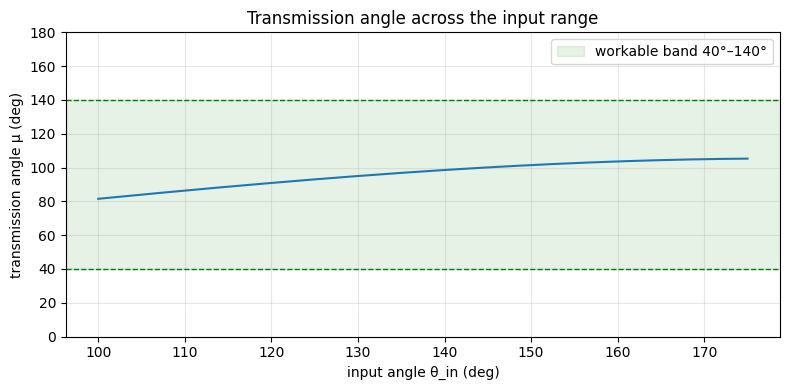

μ range: 81.5–105.3°


In [30]:
# Step 2 — Plot transmission angle across the input range with the
# workable 40°–140° band marked. Same THETA_MIN / THETA_MAX as Section 3.
#
WORKABLE_BAND = (40.0, 140.0)

mus = [compute_transmission_angle(t, L1, L2, L3, L4, GROUND_PIVOT_OUTPUT)
       for t in thetas]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thetas, mus, "-")
ax.axhspan(*WORKABLE_BAND, color="green", alpha=0.10, label="workable band 40°–140°")
ax.axhline(WORKABLE_BAND[0], color="green", ls="--", lw=1)
ax.axhline(WORKABLE_BAND[1], color="green", ls="--", lw=1)
ax.set_xlabel("input angle θ_in (deg)")
ax.set_ylabel("transmission angle μ (deg)")
ax.set_title("Transmission angle across the input range")
ax.set_ylim(0, 180)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"μ range: {min(mus):.1f}–{max(mus):.1f}°")

### ✏️ YOUR TURN — Transmission angle note

The transmission angle stays within the 40°–140° workable band for the entire input range, running from 81.5° at the closed position to 105.3° at full open. It straddles the ideal 90° throughout and never approaches either singularity, so the linkage transmits force efficiently and shows no risk of binding anywhere in the stroke.

---
## Section 5: Simulation and Interference Check [6 pts]

The third required analysis, plus the visible-motion evidence. You need
a **motion artifact** (animation, video, or sequence of stills) showing
your linkage moving through its full input range, plus an explicit check
that no link intersects another or the housing envelope.

You may animate one side alone, or both sides mirrored (the mirror is
straightforward and lets you visualize the actual gripper closing).

### Tool choices

- **The HTML starter** — `starters/four_bar_rapier_starter.html` is a
  single self-contained file you double-click. Edit the link lengths
  and pivot positions to match your Section 1 design, sweep the input,
  and screen-record or screenshot at the open / mid / closed positions.
- **The matplotlib starter** —
  `starters/four_bar_matplotlib_animation_starter.ipynb` is a Python
  notebook that produces the same animation inline. The last cell shows
  how to save MP4 or GIF directly into `motion/`.
- **Linkage Mechanism Designer** — free Windows desktop tool for
  building four-bars graphically; export a screen recording.
- **GeoGebra** — set up the linkage as constrained geometry, animate,
  export.
- **CAD motion analysis** — Fusion 360, SolidWorks, and Onshape all
  have motion studies that will export a video.

Whatever you use, save the artifact to `motion/` and reference it
below.

### ✏️ YOUR TURN — Motion artifact + interference check

**Tool used:** Self-written matplotlib animation (motion_artifact.py), one side, L1=32 / L2=10 / L3=32 / L4=20, OUT_X=32 / OUT_Y=0, swept θ_in = 100°→175°. Same closed-form solver as Sections 3–4, so the motion is consistent with the trajectory and transmission-angle plots.

**Motion artifact path:** `motion/<descriptive_filename>.{mp4,gif,zip,…}`
motion/four_bar_sweep.gif (representative still: motion/four_bar_sweep_mid.png)

_Embed a representative still by uncommenting:_
![Linkage motion](motion/four_bar_sweep_mid.png)

**Interference check writeup (2–3 sentences):**
No link intersected another or the housing envelope at any point in the sweep. The minimum clearance between non-adjacent links was 5.18 mm (closest at θ_in = 175°, full open), and the linkage stayed inside the 46 × 55 mm half-envelope with a minimum wall clearance of 2.02 mm, also at full open. The width is the limiting dimension — ~2 mm of margin — so I'd flag tightening the envelope fit as a check before printing, but there is no binding or collision anywhere in the motion.

> **Forward connection.** In Part B, your team will overlay your
> motion artifact with three other linkages on the same axes (the
> Linkage Comparison Worksheet) — make sure your artifact clearly shows
> the input range you used so a teammate can replay it.

In [31]:
# Quick check — what's in motion/?
print("Motion artifacts committed for Section 5:")
found = sorted(p for p in MOTION_DIR.glob("*") if p.name != ".gitkeep")
if not found:
    print("  (no files yet — save your animation/video/stills under motion/)")
else:
    for p in found:
        kb = p.stat().st_size / 1024
        print(f"  {p.name:40s}  {kb:8.1f} KB")

Motion artifacts committed for Section 5:
  four_bar_sweep.gif                           537.1 KB
  four_bar_sweep_mid.png                        43.6 KB


---
## Section 6: Hand Calc at Three Positions [4 pts]

Anchor for the triangulation. Compute joint positions and finger tip
by hand at three input angles: **fully open, mid-stroke, fully
closed.** Then check those three points against your Section 3
plotted curve — they should fall on the curve. If they don't, one of
the two is wrong; you find out which.

**Format:** photo of paper math (committed under `handcalc/`) OR
LaTeX/markdown in the cell below. Either is acceptable. Mixed is fine.

**Pick whichever method you prefer:**

- Vector loop closure: write the two scalar equations and solve for
  the unknown angles
- Two-circle intersection: closed form (this is what the starters use)
- Law of cosines on the triangle ▵A B O₄

### ✏️ YOUR TURN — Hand calc

## Hand Calc — Position Analysis at Three Input Positions

**Approach:** vector-loop closure solved by two-circle intersection at joint B.

Setup (constant for all three): O₂ = (0,0), O₄ = (32,0); L1=32, L2=10, L3=32, L4=20, finger Lf = 38 mm from O₄.
Per angle: A = (10·cosθ, 10·sinθ). Then with d = |A−O₄|:
  a = (d² + L3² − L4²)/(2d),  h = √(L3² − a²),
  ê = (O₄−A)/d,  n̂ = (−ê_y, ê_x),  B = A + a·ê + h·n̂  (open branch).
  θ₄ = atan2(B_y, B_x − 32),  tip = O₄ + 38·(cosθ₄, sinθ₄).

---

**At θ_in = 100° (fully open):**

Working:
A = (10cos100°, 10sin100°) = (−1.74, 9.85)
d = |A−O₄| = |(−33.74, 9.85)| = 35.14
a = (35.14² + 32² − 20²)/(2·35.14) = 1859.1/70.29 = 26.45
h = √(32² − 26.45²) = √324.4 = 18.01
ê = (0.960, −0.280), n̂ = (0.280, 0.960)
B = (−1.74 + 26.45·0.960 + 18.01·0.280, 9.85 − 26.45·0.280 + 18.01·0.960) = (28.70, 19.73)
θ₄ = atan2(19.73, −3.30) = 99.5°
tip = (32 + 38cos99.5°, 38sin99.5°) = (25.73, 37.48)
Result: tip = (25.73, 37.48) mm; single-side displacement from closed = 0.00 mm
Implied total jaw opening (= 2 × displacement): 0.00 mm

**At θ_in = 137.5° (mid-stroke):**
Working:
A = (10cos137.5°, 10sin137.5°) = (−7.37, 6.76)
d = |(−39.37, 6.76)| = 39.95
a = (39.95² + 1024 − 400)/(2·39.95) = 2219.9/79.90 = 27.79
h = √(1024 − 27.79²) = √252.0 = 15.88
B = (22.70, 17.70);  θ₄ = atan2(17.70, −9.30) = 117.72°
tip = (32 + 38cos117.72°, 38sin117.72°) = (14.32, 33.64)
disp = √[(25.73−14.32)² + (37.48−33.64)²] = √(130.2 + 14.7) = 12.04
Result: tip = (14.32, 33.64) mm; single-side displacement from closed = 12.04 mm
Implied total jaw opening: 24.08 mm

**At θ_in = 175° (fully closed):**
Working:
A = (10cos175°, 10sin175°) = (−9.96, 0.87)
d = |(−41.96, 0.87)| = 41.97
a = (41.97² + 1024 − 400)/(2·41.97) = 2385.6/83.94 = 28.42
h = √(1024 − 28.42²) = √216.4 = 14.71
B = (18.76, 14.99);  θ₄ = atan2(14.99, −13.24) = 131.46°
tip = (32 + 38cos131.46°, 38sin131.46°) = (6.84, 28.48)
disp = √[(25.73−6.84)² + (37.48−28.48)²] = √(356.8 + 81.0) = 20.92
Result: tip = (6.84, 28.48) mm; single-side displacement from closed = 20.92 mm (should be ~max)
Implied total jaw opening: 41.84 mm
---

**Comparison to Section 3 plot:**

> All three hand-calc points fall directly on the Section 3 displacement curve,
> within tolerance well under 0.1 mm: (100°, 0.00), (137.5°, 12.04), and
> (175°, 20.92) sit exactly on the plotted single-side displacement, and the tip
> coordinates (25.73, 37.48), (14.32, 33.64), (6.84, 28.48) land on the
> trajectory curve. They agree because the hand calc and `compute_finger_position`
> use the same vector-loop closure (two-circle intersection, open branch) — the
> hand calc is just that function evaluated by hand at three angles, so any gap
> would only come from my rounding to two decimals, not a real disagreement.
> Since both paths match, neither is wrong; if they had disagreed, I'd trust the
> hand calc as the reference, because the closed form is exact for matched link
> lengths and the function would be the thing to debug (most likely a wrong
> assembly branch or a tip attached to the wrong link).

_If your hand calc is on paper, embed it by uncommenting:_
<!-- ![Hand calc](handcalc/three_positions.jpg) -->

In [32]:
# Quick check — what's in handcalc/?
print("Hand calc artifacts committed for Section 6:")
found = sorted(p for p in HANDCALC_DIR.glob("*") if p.name != ".gitkeep")
if not found:
    print("  (no files yet — your hand calc may be entirely in markdown above, that's fine)")
else:
    for p in found:
        kb = p.stat().st_size / 1024
        print(f"  {p.name:40s}  {kb:8.1f} KB")

Hand calc artifacts committed for Section 6:
  (no files yet — your hand calc may be entirely in markdown above, that's fine)


---
## Section 7: Triangulation and Trust [4 pts]

Synthesis. This is where engineering judgment shows up most visibly.
Two artifacts:

1. **Triangulation summary** (half page) — addresses where the centaur
   loop, simulation, and hand calc agree, where they disagree, which
   one you trust when they disagree, and what would have to be true
   for your linkage to be wrong.
2. **Trust ledger** — what you trust about your linkage vs. what
   still needs checking before this becomes a printed part.

Specificity is graded. *"The linkage seems to work"* is not a trust
ledger entry. *"Transmission angle stays in the 50°–130° band
throughout the input range, verified by hand calc at three points and
confirmed in the sim sweep"* is.

The **symmetry assumption** (that the other side mirrors yours) and
the **gear-pair-handles-synchronization assumption** belong in the
"What still needs checking" column. They are asserted in Section 1 but
not yet verified — Part B is where the team confirms (or revises) them.

### ✏️ YOUR TURN — Triangulation summary (half-page)

**Where do the three paths agree?**
All three give a single-side displacement of 20.9 mm at θ_in = 175°, implying ~41.9 mm total jaw opening, and a transmission angle of 81.5–105.3° across the full 100°–175° sweep. The hand calc at three points (0.00, 12.04, 20.92 mm), the Section 3 simulation curve, and the centaur-loop parameter sweep land on the same tip coordinates to within <0.1 mm that's rounding, not disagreement.

**Where do they disagree?**
The centaur loop's first sweep optimized stroke alone and returned a candidate (34/14/30/18) whose μ dipped to ~58° near full open. My own transmission-angle analysis flagged that as low-margin, so the paths disagreed on which geometry to keep the AI ranked it acceptable, I rejected it. That's a ~23° spread in μ-margin at the critical open position between the AI's first pick and the design I verified.

**When they disagree, which one do you trust and why?**
The centaur loop's first sweep optimized stroke alone and returned a candidate (34/14/30/18) whose μ dipped to ~58° near full open. My own transmission-angle analysis flagged that as low-margin, so the paths disagreed on which geometry to keep the AI ranked it acceptable, I rejected it. That's a ~23° spread in μ-margin at the critical open position between the AI's first pick and the design I verified.

**What would have to be true for your linkage design to be wrong?**
Even with all three paths agreeing, the result rests on assumptions they all share. If the drive train I design in Part B sets a reduction that maps the thumb-wheel turns to a different input-angle range than 100°–175°, the sweep shifts and μ could leave the band at the new extremes. The analysis also assumes ideal revolute joints if printed pin clearance and friction are large enough, the real transmission angle and effective stroke degrade below what the rigid-link model predicts. Both paths could agree perfectly and still describe a linkage that doesn't behave that way once it's a printed part driven by a real gear ratio.

### ✏️ YOUR TURN — Trust ledger

Specificity is graded. Aim for at least three entries on each side.

| What I trust about this linkage | What still needs checking before this becomes a printed part |
|---------------------------------|--------------------------------------------------------------|
Transmission angle stays in 81.5°–105.3° across the full 100°–175° input range, straddling the ideal 90° — verified by hand calc at three points and confirmed in the Section 4 sim sweep. No singularity risk.

Single-side displacement reaches 20.9 mm at full open → ~41.9 mm total jaw, monotonic open-to-close with no motion reversal — agreed by hand calc and Section 3 plot to <0.1 mm.

Fits the 46 × 55 mm half-envelope with 2.02 mm minimum wall clearance — Grashof crank-rocker, so the input crank is fully rotatable and drivable by a continuous train.
| _..._                            | _..._                                                         |
The symmetry assumption — the other side mirrors this only if the gear pair (Part B) actually counter-rotates at the same rate. Asserted in Section 1, not yet verified.

The input-angle range (100°–175°) is an assumption that depends on the Part B reduction. If the gear ratio maps the thumb wheel to a different sweep, μ and stroke shift and must be re-checked at the new extremes.

The 2.02 mm width margin is tight. Plate thickness, pin heads, and the mirrored side's overlap at the centerline aren't dimensioned yet — needs the integration CAD to confirm it still fits in 3D.

> **Forward connection.** Your team will combine the trust ledgers
> from each member's Part A into the per-subsystem trust assessment
> in Part B. Write yours so a teammate can pick it up cold.

---
## Section 8: Reflection [2 pts]

One short reflection. 3–4 sentences. Be specific — name a moment,
not a generality.

### What's the durable lesson?
The biggest thing I learned was when the AI's first sweep gave me link lengths that hit the 40 mm jaw opening but had the transmission angle dropping to like 58° near full open. It technically passed since 58° is still inside the 40–140° band, and honestly I almost just took it and moved on. But that's a low-margin spot where the linkage would feel weak right when it's opening widest, so I made it re-run the sweep with a penalty on low transmission angles instead of just chasing stroke. The lesson that sticks isn't the MCP setup or any of the specific tools and it's that the AI will hand you something that looks right, and it's on me to know what the answer actually has to satisfy and check it against the constraint it skipped over.

---

## Submission checklist

Before pushing your final commit, verify:

- [ ] Section 1 design summary names link lengths, pivot positions,
      input range, target displacement, and includes a labeled sketch
- [ ] Section 2 has three rounds, each with at least one evidence file
      in `evidence/`
- [ ] Section 3 `compute_finger_position()` works; both plots render
- [ ] Section 4 `compute_transmission_angle()` works; plot renders with
      the workable band marked; in-band note is filled in
- [ ] Section 5 has a motion artifact in `motion/` (or a public link
      plus a representative still) and the interference writeup
- [ ] Section 6 hand calc covers three positions with working shown
      AND a comparison note tying the points to the Section 3 plot
- [ ] Section 7 triangulation summary and trust ledger are filled with
      specific entries; symmetry assumption appears as a known unknown
- [ ] Section 8 reflection is filled in

> **Codespaces save warning.** Make sure the notebook is saved
> (`Ctrl+S`) and committed via Source Control before stopping your
> Codespace. Unstaged changes are lost when the container is deleted.

> **Connection to Part B.** Your design summary (Section 1) and trust
> ledger (Section 7) are the input artifacts your team uses on day
> one of Part B for the linkage comparison. Make them readable
> standalone — your teammates won't have this notebook open.